## 1. Setup and Data Loading

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple
import warnings
import sys
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Setup plotting
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries loaded successfully!")

✓ Libraries loaded successfully!


In [2]:
DATASET = "InfographicVQA_mini"
DATA_DIR = Path("../../../2_clean") / DATASET

# Define phases and their descriptions  
PHASES = {
    "QA1a": "OCR Pipeline - Simple Prompts (azure_intelligence + mistral)",
    "QA1b": "OCR Pipeline - Detailed Prompts (azure_intelligence + mistral)",
    "QA1c": "OCR Pipeline - Chain-of-Thought (azure_intelligence + mistral)",
    "QA2a": "VLM Parse Pipeline - Simple (gpt-5-mini + gpt-5-nano)",
    "QA2b": "VLM Parse Pipeline - Detailed (gpt-5-mini + gpt-5-nano)",
    "QA2c": "VLM Parse Pipeline - Chain-of-Thought (gpt-5-mini + gpt-5-nano)",
    "QA3a": "Direct VQA - Simple (gpt-5-mini + gpt-5-nano)",
    "QA3b": "Direct VQA - Chain-of-Thought (gpt-5-mini + gpt-5-nano)",
    "QA4a": "Pre-extracted OCR Pipeline - Simple (AWS Textract)",
    "QA4b": "Pre-extracted OCR Pipeline - Detailed (AWS Textract)",
    "QA4c": "Pre-extracted OCR Pipeline - Chain-of-Thought (AWS Textract)",
}

# Phase groupings (NOTE: QA4 is unique to InfographicVQA)
APPROACH_GROUPS = {
    "OCR Pipeline": ["QA1a", "QA1b", "QA1c"],
    "VLM Parse Pipeline": ["QA2a", "QA2b", "QA2c"],
    "Direct VQA": ["QA3a", "QA3b"],
    "Pre-extracted OCR Pipeline": ["QA4a", "QA4b", "QA4c"],  # UNIQUE
}

print(f"Dataset: {DATASET}")
print(f"Data Directory: {DATA_DIR}")
print(f"Phases to analyze: {len(PHASES)}")
for phase, desc in PHASES.items():
    print(f"  - {phase}: {desc}")

Dataset: InfographicVQA_mini
Data Directory: ../../../2_clean/InfographicVQA_mini
Phases to analyze: 11
  - QA1a: OCR Pipeline - Simple Prompts (azure_intelligence + mistral)
  - QA1b: OCR Pipeline - Detailed Prompts (azure_intelligence + mistral)
  - QA1c: OCR Pipeline - Chain-of-Thought (azure_intelligence + mistral)
  - QA2a: VLM Parse Pipeline - Simple (gpt-5-mini + gpt-5-nano)
  - QA2b: VLM Parse Pipeline - Detailed (gpt-5-mini + gpt-5-nano)
  - QA2c: VLM Parse Pipeline - Chain-of-Thought (gpt-5-mini + gpt-5-nano)
  - QA3a: Direct VQA - Simple (gpt-5-mini + gpt-5-nano)
  - QA3b: Direct VQA - Chain-of-Thought (gpt-5-mini + gpt-5-nano)
  - QA4a: Pre-extracted OCR Pipeline - Simple (AWS Textract)
  - QA4b: Pre-extracted OCR Pipeline - Detailed (AWS Textract)
  - QA4c: Pre-extracted OCR Pipeline - Chain-of-Thought (AWS Textract)


In [3]:
# Load all phase CSV files
all_results = {}
for phase in PHASES.keys():
    phase_file = DATA_DIR / f"{phase}.csv"
    if not phase_file.exists():
        print(f"⚠ Phase {phase} file not found at {phase_file}")
        continue
    
    df = pd.read_csv(phase_file)
    all_results[phase] = df
    
    # Extract model names from column names (prediction_* columns)
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols]
    
    print(f"✓ Phase {phase}: {len(df)} samples, {len(models)} models: {', '.join(models)}")

print(f"\n✓ Loaded results for {len(all_results)} phases")

✓ Phase QA1a: 500 samples, 12 models: azure_intelligence__gpt-5-mini, in_ground_truth_azure_intelligence__gpt-5-mini, in_ground_truth_azure_intelligence__gpt-5-mini.1, in_ground_truth_in_ground_truth_azure_intelligence__gpt-5-mini, in_ground_truth_in_ground_truth_azure_intelligence__gpt-5-mini.1, in_ground_truth_in_ground_truth_in_ground_truth_azure_intelligence__gpt-5-mini, in_ground_truth_in_ground_truth_mistral_document_ai__gpt-5-mini, in_ground_truth_in_ground_truth_in_ground_truth_mistral_document_ai__gpt-5-mini, in_ground_truth_mistral_document_ai__gpt-5-mini, in_ground_truth_in_ground_truth_mistral_document_ai__gpt-5-mini.1, mistral_document_ai__gpt-5-mini, in_ground_truth_mistral_document_ai__gpt-5-mini.1
✓ Phase QA1b: 500 samples, 12 models: azure_intelligence__gpt-5-mini, in_ground_truth_azure_intelligence__gpt-5-mini, in_ground_truth_azure_intelligence__gpt-5-mini.1, in_ground_truth_in_ground_truth_azure_intelligence__gpt-5-mini, in_ground_truth_in_ground_truth_azure_intelli

In [4]:
# Extract models from all phases
all_models = set()
for phase in all_results.keys():
    df = all_results[phase]
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols]
    all_models.update(models)

print("All models across phases:")
for model in sorted(all_models):
    print(f"  - {model}")

All models across phases:
  - azure_intelligence__gpt-5-mini
  - claude_sonnet
  - gpt-5-mini
  - gpt-5-mini__gpt-5-mini
  - gpt-5-nano
  - gpt-5-nano__gpt-5-mini
  - in_ground_truth_azure_intelligence__gpt-5-mini
  - in_ground_truth_azure_intelligence__gpt-5-mini.1
  - in_ground_truth_claude_sonnet
  - in_ground_truth_claude_sonnet.1
  - in_ground_truth_gpt-5-mini
  - in_ground_truth_gpt-5-mini.1
  - in_ground_truth_gpt-5-mini__gpt-5-mini
  - in_ground_truth_gpt-5-mini__gpt-5-mini.1
  - in_ground_truth_gpt-5-nano
  - in_ground_truth_gpt-5-nano.1
  - in_ground_truth_gpt-5-nano__gpt-5-mini
  - in_ground_truth_gpt-5-nano__gpt-5-mini.1
  - in_ground_truth_in_ground_truth_azure_intelligence__gpt-5-mini
  - in_ground_truth_in_ground_truth_azure_intelligence__gpt-5-mini.1
  - in_ground_truth_in_ground_truth_claude_sonnet
  - in_ground_truth_in_ground_truth_claude_sonnet.1
  - in_ground_truth_in_ground_truth_gpt-5-mini
  - in_ground_truth_in_ground_truth_gpt-5-mini.1
  - in_ground_truth_in_gr

## 📊 Data Preview

Quick look at 10 random samples showing ground truth vs model predictions.

In [5]:
# ============================================================================
# DATA PREVIEW: Ground Truth vs Predictions (10 Random Samples)
# ============================================================================

# Load one phase to show examples
phase_to_preview = 'QA1a'
dataset_name = 'InfographicVQA_mini'

preview_file = f"../../../2_clean/{dataset_name}/{phase_to_preview}.csv"

if Path(preview_file).exists():
    df_preview = pd.read_csv(preview_file)

    # Get 10 random samples
    random_samples = df_preview.sample(n=min(10, len(df_preview)), random_state=42)

    # Extract columns for preview
    columns_to_show = ['sample_id', 'question', 'ground_truths']

    # Add prediction columns (find all columns starting with 'prediction_')
    pred_cols = [col for col in df_preview.columns if col.startswith('prediction_')]
    columns_to_show.extend(pred_cols[:2])  # Show first 2 models

    # Create display dataframe
    display_df = random_samples[columns_to_show].copy()

    # Truncate long strings for readability
    for col in display_df.columns:
        if display_df[col].dtype == 'object':
            display_df[col] = display_df[col].apply(
                lambda x: str(x)[:100] + '...' if pd.notna(x) and len(str(x)) > 100 else x
            )

    print(f"\n{'='*100}")
    print(f"DATA PREVIEW: {dataset_name} - {phase_to_preview}")
    print(f"Showing 10 random samples with ground truth and first 2 model predictions")
    print(f"{'='*100}\n")

    display(display_df)

    print(f"\nTotal samples in {phase_to_preview}: {len(df_preview)}")
    print(f"Available models: {', '.join([col.replace('prediction_', '') for col in pred_cols])}")
else:
    print(f"Preview file not found: {preview_file}")


DATA PREVIEW: InfographicVQA_mini - QA1a
Showing 10 random samples with ground truth and first 2 model predictions



,sample_id,question,ground_truths,prediction_azure_intelligence__gpt-5-mini,prediction_in_ground_truth_azure_intelligence__gpt-5-mini
361,infovqa_mini_0361,Which is the IOT application shown in the infographic in green background color?,"[""whatsapp""]",WhatsApp,1.0000
73,infovqa_mini_0073,What percentage of respondents backup photos on cloud according to the survey?,"[""45.3%"", ""45.3""]",45.3%,1.0000
374,infovqa_mini_0374,What is the ticket price (in dollars) for the quarter-finals of the 2015 ICC Cricket World Cup?,"[""$50.87"", ""50.87""]",$50.87,1.0000
155,infovqa_mini_0155,Which topic received the second highest mentions on media ?,"[""ppe""]","PPE — personal protective equipment, with 1,589 mentions.",0.0000
104,infovqa_mini_0104,What is total percentage of businesses laying of staff and reducing staff hours?,"[""68.3%"", ""68.3""]",68.3% (39.9% reduced staff hours/shifts + 28.4% laid off staff),0.0000
394,infovqa_mini_0394,What percentage of the survey respondents are non-travelers?,"[""44%"", ""44""]",44%,1.0000
377,infovqa_mini_0377,"Besides earth, which are the other two planets featured in the movie Thor?","[""asgard, jotunheim"", ""jotunheim, asgard""]",Asgard and Jotunheim.,0.0000
124,infovqa_mini_0124,Who is the author of Stand on Zanzibar?,"[""john brunner""]",John Brunner,1.0000
68,infovqa_mini_0068,Which social media platform is ranked #1?,"[""facebook""]",Facebook,1.0000
450,infovqa_mini_0450,What percentage of Americans have an e-reader as of January 2014?,"[""32%"", ""32""]",32%,1.0000



Total samples in QA1a: 500
Available models: azure_intelligence__gpt-5-mini, in_ground_truth_azure_intelligence__gpt-5-mini, in_ground_truth_azure_intelligence__gpt-5-mini.1, in_ground_truth_in_ground_truth_azure_intelligence__gpt-5-mini, in_ground_truth_in_ground_truth_azure_intelligence__gpt-5-mini.1, in_ground_truth_in_ground_truth_in_ground_truth_azure_intelligence__gpt-5-mini, in_ground_truth_in_ground_truth_mistral_document_ai__gpt-5-mini, in_ground_truth_in_ground_truth_in_ground_truth_mistral_document_ai__gpt-5-mini, in_ground_truth_mistral_document_ai__gpt-5-mini, in_ground_truth_in_ground_truth_mistral_document_ai__gpt-5-mini.1, mistral_document_ai__gpt-5-mini, in_ground_truth_mistral_document_ai__gpt-5-mini.1


# InfographicVQA QA Benchmark Evaluation

Comprehensive evaluation of OCR and Question Answering (QA) performance on the InfographicVQA mini dataset with **unique pre-extracted OCR analysis**.

## Pipeline Overview

**QA Phases (11 total):**
- **QA-OCR_LLM_simple/c/detailed/cot**: OCR Pipeline (Extract text via OCR → Answer QA based on extracted text)
  - QA-OCR_LLM_simple: Simple prompts
  - QA-OCR_LLM_detailed: Detailed prompts with context
  - QA-OCR_LLM_cot: Chain-of-Thought prompting
  
- **QA-VLM_LLM_simple/c/detailed/cot**: VLM Parse Pipeline (Parse document with VLM → Answer QA based on parsed output)
  - QA-VLM_LLM_simple: Simple prompts
  - QA-VLM_LLM_detailed: Detailed prompts
  - QA-VLM_LLM_cot: Chain-of-Thought prompting
  
- **QA-VLM_direct_simple/detailed**: Direct VQA (VLM answers directly from image)
  - QA-VLM_direct_simple: Simple prompts
  - QA-VLM_direct_detailed: Chain-of-Thought prompting

- **QA-EXT_OCR_LLM_simple/c/detailed/cot**: Pre-extracted OCR Pipeline ⭐ UNIQUE to InfographicVQA
  - Uses AWS Textract OCR from metadata
  - QA-EXT_OCR_LLM_simple: Simple prompts
  - QA-EXT_OCR_LLM_detailed: Detailed prompts
  - QA-EXT_OCR_LLM_cot: Chain-of-Thought prompting

**Models Evaluated:**
- OCR (QA1): `azure_intelligence`, `mistral_document_ai`
- VLM (QA2): `gpt-5-mini`, `gpt-5-nano`
- Direct VQA (QA3): `gpt-5-mini`, `gpt-5-nano`
- Pre-extracted OCR (QA4): AWS Textract (metadata)
- QA: `gpt-5-mini`

## 2. OCR Evaluation Metrics

In [6]:
def analyze_extracted_text(df: pd.DataFrame) -> Dict:
    """Analyze OCR extraction quality from extracted_text column."""
    results = {
        'total_samples': len(df),
        'samples_with_text': (df['extracted_text'].notna() & (df['extracted_text'] != '')).sum(),
        'empty_extractions': (df['extracted_text'].isna() | (df['extracted_text'] == '')).sum(),
        'avg_text_length': df['extracted_text'].fillna('').apply(lambda x: len(str(x))).mean(),
        'median_text_length': df['extracted_text'].fillna('').apply(lambda x: len(str(x))).median(),
    }
    results['extraction_success_rate'] = results['samples_with_text'] / results['total_samples']
    return results

# Analyze OCR extraction for QA1 phases (OCR Pipeline)
print("OCR Extraction Analysis (QA1 phases - OCR Pipeline)")
print("=" * 70)
ocr_phases = ["QA-OCR_LLM_simple", "QA-OCR_LLM_detailed", "QA-OCR_LLM_cot"]
ocr_analysis = {}

for phase in ocr_phases:
    if phase not in all_results:
        continue
    df = all_results[phase]
    analysis = analyze_extracted_text(df)
    ocr_analysis[phase] = analysis
    
    print(f"\n{phase}:")
    print(f"  Total samples: {analysis['total_samples']}")
    print(f"  Successful extractions: {analysis['samples_with_text']} ({analysis['extraction_success_rate']*100:.1f}%)")
    print(f"  Avg text length: {analysis['avg_text_length']:.0f} chars")
    print(f"  Median text length: {analysis['median_text_length']:.0f} chars")

# Analyze pre-extracted OCR (QA4 phases) - unique to InfographicVQA
print("\n\nPre-extracted OCR Analysis (QA4 phases - AWS Textract from metadata) ⭐")
print("=" * 70)
preextracted_ocr_phases = ["QA-EXT_OCR_LLM_simple", "QA-EXT_OCR_LLM_detailed", "QA-EXT_OCR_LLM_cot"]
for phase in preextracted_ocr_phases:
    if phase not in all_results:
        continue
    df = all_results[phase]
    analysis = analyze_extracted_text(df)
    
    print(f"\n{phase}:")
    print(f"  Total samples: {analysis['total_samples']}")
    print(f"  Successful extractions: {analysis['samples_with_text']} ({analysis['extraction_success_rate']*100:.1f}%)")
    print(f"  Avg text length: {analysis['avg_text_length']:.0f} chars")
    print(f"  Median text length: {analysis['median_text_length']:.0f} chars")

OCR Extraction Analysis (QA1 phases - OCR Pipeline)


Pre-extracted OCR Analysis (QA4 phases - AWS Textract from metadata) ⭐


## 3. OCR Performance Analysis

In [7]:
# Analyze which OCR models appear in each QA1 phase
print("OCR Models in QA1 Phases:")
print("=" * 70)
for phase in ocr_phases:
    if phase not in all_results:
        continue
    df = all_results[phase]
    models = df['parsing_model'].unique()
    print(f"\n{phase}:")
    for model in sorted(models):
        count = (df['parsing_model'] == model).sum()
        print(f"  {model}: {count} samples")

# Note about QA4: Pre-extracted OCR comes from metadata (AWS Textract)
print("QA-EXT_OCR_LLM Phases (Pre-extracted OCR) ⭐:")
print("=" * 70)
print("QA-EXT_OCR_LLM_simple/c/detailed/cot: Pre-extracted OCR from AWS Textract metadata")
print("  - Not model-dependent (uses fixed metadata)")
print("  - Serves as upper bound for 'perfect' OCR scenario")

OCR Models in QA1 Phases:
QA-EXT_OCR_LLM Phases (Pre-extracted OCR) ⭐:
QA-EXT_OCR_LLM_simple/c/detailed/cot: Pre-extracted OCR from AWS Textract metadata
  - Not model-dependent (uses fixed metadata)
  - Serves as upper bound for 'perfect' OCR scenario


## 4. QA Evaluation Metrics

In [8]:
# Extract QA metrics from consolidated CSVs (metrics already computed!)
print("QA Performance Metrics from Consolidated Data")
print("=" * 80)

qa_metrics = []
for phase, desc in PHASES.items():
    if phase not in all_results:
        continue
    
    df = all_results[phase]
    
    # Find all models in this phase (from prediction_* columns)
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols]
    
    # For each model, extract the average metrics
    for model in models:
        anls_col = f'anls_score_{model}'
        em_col = f'exact_match_{model}'
        
        if anls_col in df.columns and em_col in df.columns:
            qa_metrics.append({
                'Phase': phase,
                'Model': model,
                'Description': desc,
                'ANLS': df[anls_col].mean(),
                'Exact Match': df[em_col].mean(),
                'Total Samples': len(df),
                'Valid Samples': df[anls_col].notna().sum(),
            })

qa_df = pd.DataFrame(qa_metrics)
print("\nAll Phase-Model Combinations:")
print(qa_df.to_string(index=False))

QA Performance Metrics from Consolidated Data

All Phase-Model Combinations:
Phase                                                           Model                                                     Description   ANLS  Exact Match  Total Samples  Valid Samples
 QA1a                                  azure_intelligence__gpt-5-mini    OCR Pipeline - Simple Prompts (azure_intelligence + mistral) 0.4275       0.3380            500            500
 QA1a                  in_ground_truth_azure_intelligence__gpt-5-mini    OCR Pipeline - Simple Prompts (azure_intelligence + mistral)    NaN          NaN            500              0
 QA1a  in_ground_truth_in_ground_truth_azure_intelligence__gpt-5-mini    OCR Pipeline - Simple Prompts (azure_intelligence + mistral)    NaN          NaN            500              0
 QA1a in_ground_truth_in_ground_truth_mistral_document_ai__gpt-5-mini    OCR Pipeline - Simple Prompts (azure_intelligence + mistral)    NaN          NaN            500              0
 QA

In [9]:
# Aggregate metrics by phase (average across all models in phase)
print("\nAggregate Metrics by Phase:")
print("=" * 80)

phase_metrics = []
for phase in PHASES.keys():
    if phase not in all_results:
        continue
    
    df = all_results[phase]
    
    # Find all anls and em columns
    anls_cols = [col for col in df.columns if col.startswith('anls_score_')]
    em_cols = [col for col in df.columns if col.startswith('exact_match_')]
    
    if anls_cols and em_cols:
        # Average across all models
        avg_anls = df[anls_cols].mean().mean()
        avg_em = df[em_cols].mean().mean()
        
        phase_metrics.append({
            'Phase': phase,
            'ANLS': avg_anls,
            'Exact Match': avg_em,
            'Num Models': len(anls_cols),
            'Samples': len(df)
        })

phase_df = pd.DataFrame(phase_metrics)
print(phase_df.to_string(index=False))

# Store for visualizations
comprehensive_df = phase_df
approach_metrics_data = None  # Will compute later


Aggregate Metrics by Phase:
Phase   ANLS  Exact Match  Num Models  Samples
 QA1a 0.3264       0.2510           6      500
 QA1b 0.3992       0.3580           6      500
 QA1c 0.3876       0.3070           6      500
 QA2a 0.2888       0.2310           4      500
 QA2b 0.3572       0.3350           6      500
 QA2c 0.3688       0.3010           6      500
 QA3a 0.3464       0.2440           9      500
 QA3b 0.1896       0.1200           9      500
 QA4a 0.3474       0.2660           3      500
 QA4b 0.4451       0.3920           2      500
 QA4c 0.3963       0.3160           2      500


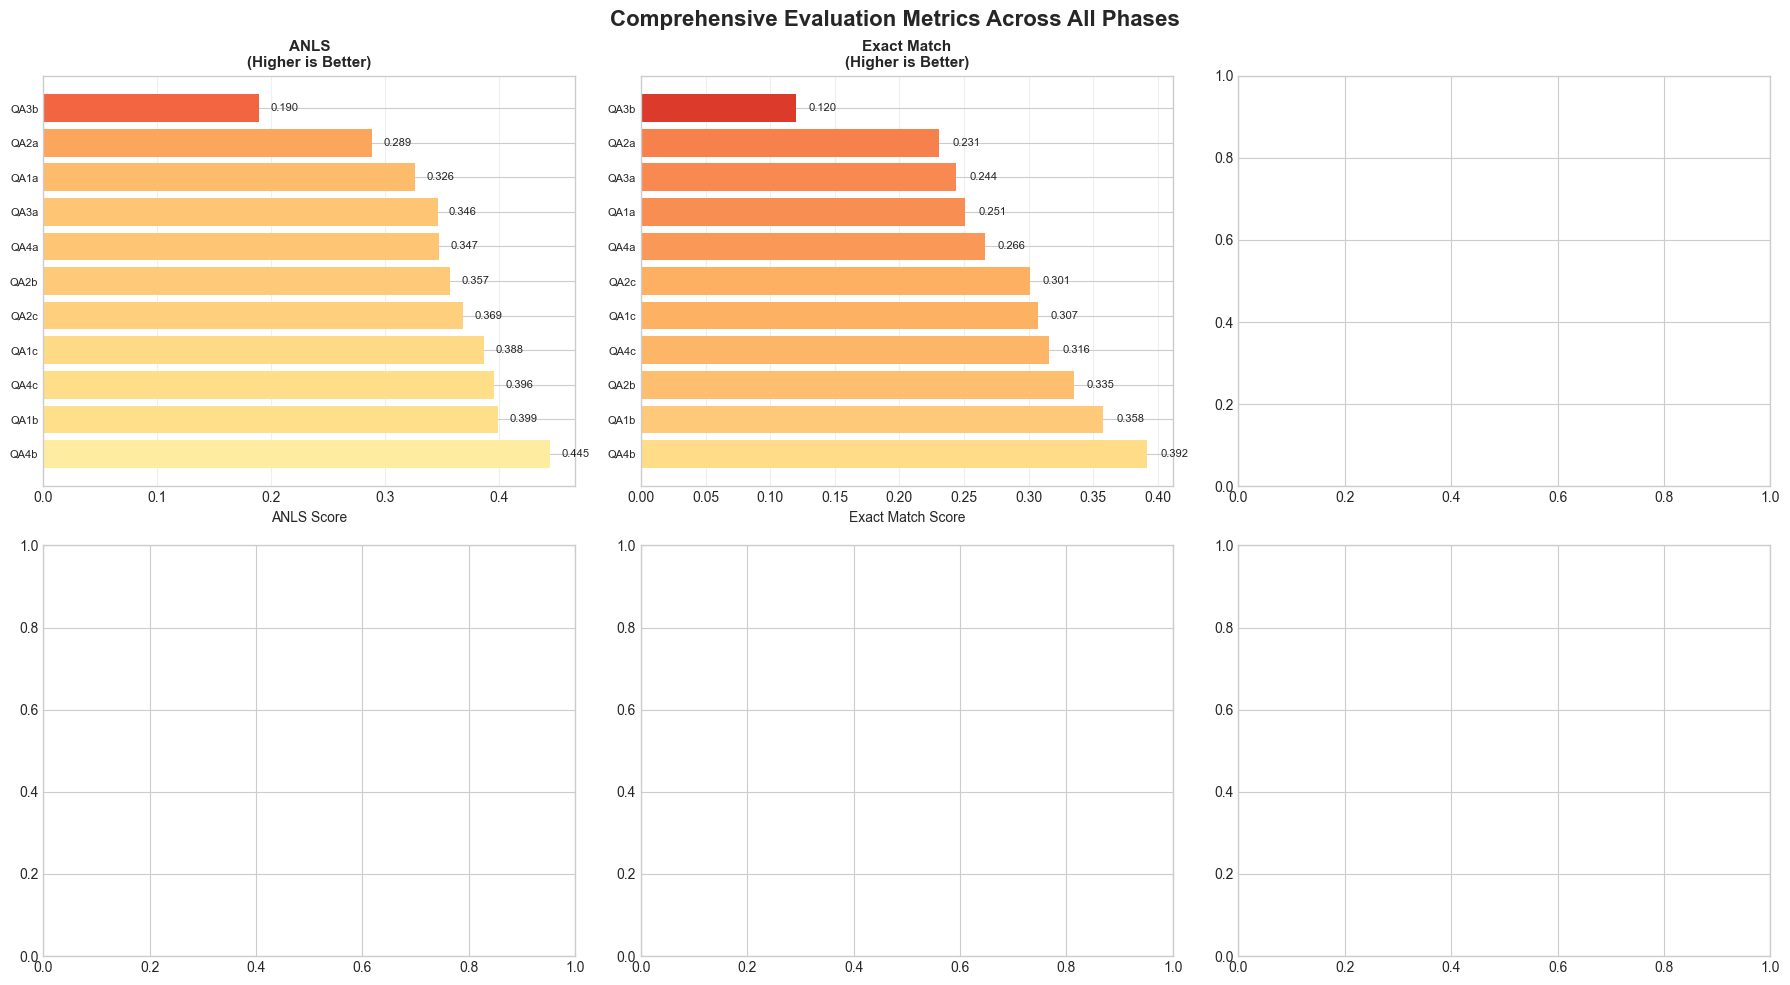

In [10]:
# Visualize all metrics comparison
if len(comprehensive_df) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Comprehensive Evaluation Metrics Across All Phases', fontsize=16, fontweight='bold')
    
    metrics_to_plot = [
        ('ANLS', 'Higher is Better'),
        ('Exact Match', 'Higher is Better'),
        ('Substring Match', 'Higher is Better'),
        ('Cosine Similarity', 'Higher is Better'),
        ('CER', 'Lower is Better'),
        ('WER', 'Lower is Better')
    ]
    
    for idx, (metric, direction) in enumerate(metrics_to_plot):
        ax = axes[idx // 3, idx % 3]
        
        if metric in comprehensive_df.columns:
            data = comprehensive_df.sort_values(metric, ascending=(direction == 'Lower is Better'))
            
            colors = plt.cm.RdYlGn(data[metric] if direction == 'Higher is Better' else 1 - data[metric])
            bars = ax.barh(range(len(data)), data[metric], color=colors)
            
            ax.set_yticks(range(len(data)))
            ax.set_yticklabels(data['Phase'], fontsize=8)
            ax.set_xlabel(f'{metric} Score', fontsize=10)
            ax.set_title(f'{metric}\n({direction})', fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3, axis='x')
            
            # Add value labels on bars
            for i, (bar, val) in enumerate(zip(bars, data[metric])):
                ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                       f'{val:.3f}', va='center', fontsize=8)
    
    plt.tight_layout()
    plt.show()
else:
    print("No comprehensive metrics available to visualize")

In [11]:
# Group metrics by approach
print("\n\nPerformance by Approach:")
print("=" * 80)

approach_metrics = []
for approach, phases in APPROACH_GROUPS.items():
    valid_phases = [p for p in phases if p in comprehensive_df['Phase'].values]
    if not valid_phases:
        continue
    
    approach_data = comprehensive_df[comprehensive_df['Phase'].isin(valid_phases)]
    
    approach_metrics.append({
        'Approach': approach,
        'Avg ANLS': approach_data['ANLS'].mean(),
        'Std ANLS': approach_data['ANLS'].std(),
        'Avg EM': approach_data['Exact Match'].mean(),
        'Std EM': approach_data['Exact Match'].std(),
        'Num Phases': len(valid_phases),
    })

approach_df = pd.DataFrame(approach_metrics)
print(approach_df.to_string(index=False))

# Store for later visualization
approach_metrics_data = approach_df



Performance by Approach:
                  Approach  Avg ANLS  Std ANLS  Avg EM  Std EM  Num Phases
              OCR Pipeline    0.3711    0.0391  0.3053  0.0535           3
        VLM Parse Pipeline    0.3382    0.0432  0.2890  0.0530           3
                Direct VQA    0.2680    0.1109  0.1820  0.0877           2
Pre-extracted OCR Pipeline    0.3963    0.0488  0.3247  0.0634           3


## 5. QA Performance Analysis

In [12]:
# Analyze prompt effectiveness within OCR Pipeline
print("\n\nPrompt Variation Analysis within OCR Pipeline (QA1 phases):")
print("=" * 80)
ocr_qa_analysis = []
for phase in ["QA1a", "QA1b", "QA1c"]:
    if phase not in comprehensive_df['Phase'].values:
        continue
    
    phase_data = comprehensive_df[comprehensive_df['Phase'] == phase].iloc[0]
    ocr_qa_analysis.append({
        'Phase': phase,
        'Prompt Style': phase[-1].upper(),
        'ANLS': phase_data['ANLS'],
        'EM': phase_data['Exact Match'],
    })

ocr_qa_df = pd.DataFrame(ocr_qa_analysis)
if len(ocr_qa_df) > 0:
    print(ocr_qa_df.to_string(index=False))
    print(f"\nBest OCR prompt variant: {ocr_qa_df.loc[ocr_qa_df['ANLS'].idxmax(), 'Phase']} (ANLS: {ocr_qa_df['ANLS'].max():.4f})")



Prompt Variation Analysis within OCR Pipeline (QA1 phases):
Phase Prompt Style   ANLS     EM
 QA1a            A 0.3264 0.2510
 QA1b            B 0.3992 0.3580
 QA1c            C 0.3876 0.3070

Best OCR prompt variant: QA1b (ANLS: 0.3992)


In [13]:
# Analyze prompt effectiveness within VLM Parse Pipeline
print("\n\nPrompt Variation Analysis within VLM Parse Pipeline (QA2 phases):")
print("=" * 80)
vlm_qa_analysis = []
for phase in ["QA2a", "QA2b", "QA2c"]:
    if phase not in comprehensive_df['Phase'].values:
        continue
    
    phase_data = comprehensive_df[comprehensive_df['Phase'] == phase].iloc[0]
    vlm_qa_analysis.append({
        'Phase': phase,
        'Prompt Style': phase[-1].upper(),
        'ANLS': phase_data['ANLS'],
        'EM': phase_data['Exact Match'],
    })

vlm_qa_df = pd.DataFrame(vlm_qa_analysis)
if len(vlm_qa_df) > 0:
    print(vlm_qa_df.to_string(index=False))
    print(f"\nBest VLM Parse prompt variant: {vlm_qa_df.loc[vlm_qa_df['ANLS'].idxmax(), 'Phase']} (ANLS: {vlm_qa_df['ANLS'].max():.4f})")



Prompt Variation Analysis within VLM Parse Pipeline (QA2 phases):
Phase Prompt Style   ANLS     EM
 QA2a            A 0.2888 0.2310
 QA2b            B 0.3572 0.3350
 QA2c            C 0.3688 0.3010

Best VLM Parse prompt variant: QA2c (ANLS: 0.3688)


In [14]:
# Analyze Direct VQA variants
print("\n\nDirect VQA Analysis (QA3 phases):")
print("=" * 80)
direct_qa_analysis = []
for phase in ["QA3a", "QA3b"]:
    if phase not in comprehensive_df['Phase'].values:
        continue
    
    phase_data = comprehensive_df[comprehensive_df['Phase'] == phase].iloc[0]
    direct_qa_analysis.append({
        'Phase': phase,
        'Prompt Style': phase[-1].upper(),
        'ANLS': phase_data['ANLS'],
        'EM': phase_data['Exact Match'],
    })

direct_qa_df = pd.DataFrame(direct_qa_analysis)
if len(direct_qa_df) > 0:
    print(direct_qa_df.to_string(index=False))
    if len(direct_qa_df) > 1:
        print(f"\nBest Direct VQA variant: {direct_qa_df.loc[direct_qa_df['ANLS'].idxmax(), 'Phase']} (ANLS: {direct_qa_df['ANLS'].max():.4f})")



Direct VQA Analysis (QA3 phases):
Phase Prompt Style   ANLS     EM
 QA3a            A 0.3464 0.2440
 QA3b            B 0.1896 0.1200

Best Direct VQA variant: QA3a (ANLS: 0.3464)


In [15]:
# Analyze Pre-extracted OCR Pipeline variants - UNIQUE TO INFOGRAPHICVQA
print("\n\nPre-extracted OCR Pipeline Analysis (QA4 phases) - UNIQUE TO INFOGRAPHICVQA:")
print("=" * 80)
preextracted_qa_analysis = []
for phase in ["QA4a", "QA4b", "QA4c"]:
    if phase not in comprehensive_df['Phase'].values:
        continue
    
    phase_data = comprehensive_df[comprehensive_df['Phase'] == phase].iloc[0]
    preextracted_qa_analysis.append({
        'Phase': phase,
        'Prompt Style': phase[-1].upper(),
        'ANLS': phase_data['ANLS'],
        'EM': phase_data['Exact Match'],
    })

preextracted_qa_df = pd.DataFrame(preextracted_qa_analysis)
if len(preextracted_qa_df) > 0:
    print(preextracted_qa_df.to_string(index=False))
    print(f"\nBest Pre-extracted OCR prompt variant: {preextracted_qa_df.loc[preextracted_qa_df['ANLS'].idxmax(), 'Phase']} (ANLS: {preextracted_qa_df['ANLS'].max():.4f})")
    print("\n💡 INSIGHT: Pre-extracted OCR from AWS Textract represents the 'upper bound'")
    print("   for OCR-based QA when using perfect/high-quality OCR extraction.")
else:
    print("No pre-extracted OCR data available")



Pre-extracted OCR Pipeline Analysis (QA4 phases) - UNIQUE TO INFOGRAPHICVQA:
Phase Prompt Style   ANLS     EM
 QA4a            A 0.3474 0.2660
 QA4b            B 0.4451 0.3920
 QA4c            C 0.3963 0.3160

Best Pre-extracted OCR prompt variant: QA4b (ANLS: 0.4451)

💡 INSIGHT: Pre-extracted OCR from AWS Textract represents the 'upper bound'
   for OCR-based QA when using perfect/high-quality OCR extraction.


## 6. Cross-Dataset & Cross-Approach Comparison

In [16]:
print("APPROACH COMPARISON - Key Metrics")
print("=" * 80)

# Get best phase from each approach
best_by_approach = {}
for approach, phases in APPROACH_GROUPS.items():
    valid_phases = [p for p in phases if p in comprehensive_df['Phase'].values]
    if valid_phases:
        approach_data = comprehensive_df[comprehensive_df['Phase'].isin(valid_phases)]
        best_phase = approach_data.loc[approach_data['ANLS'].idxmax(), 'Phase']
        best_data = approach_data[approach_data['Phase'] == best_phase].iloc[0]
        
        best_by_approach[approach] = {
            'best_phase': best_phase,
            'anls': best_data['ANLS'],
            'em': best_data['Exact Match'],
        }

for approach, data in best_by_approach.items():
    marker = " ⭐" if "Pre-extracted" in approach else ""
    print(f"\n{approach}{marker}")
    print(f"  Best phase: {data['best_phase']}")
    print(f"  ANLS: {data['anls']:.4f}")
    print(f"  Exact Match: {data['em']:.4f}")

# Overall best
if best_by_approach:
    best_overall = max(best_by_approach.items(), key=lambda x: x[1]['anls'])
    print(f"\n{'=' * 80}")
    print(f"OVERALL BEST: {best_overall[0]} (Phase: {best_overall[1]['best_phase']})")
    print(f"ANLS: {best_overall[1]['anls']:.4f} | EM: {best_overall[1]['em']:.4f}")

APPROACH COMPARISON - Key Metrics

OCR Pipeline
  Best phase: QA1b
  ANLS: 0.3992
  Exact Match: 0.3580

VLM Parse Pipeline
  Best phase: QA2c
  ANLS: 0.3688
  Exact Match: 0.3010

Direct VQA
  Best phase: QA3a
  ANLS: 0.3464
  Exact Match: 0.2440

Pre-extracted OCR Pipeline ⭐
  Best phase: QA4b
  ANLS: 0.4451
  Exact Match: 0.3920

OVERALL BEST: Pre-extracted OCR Pipeline (Phase: QA4b)
ANLS: 0.4451 | EM: 0.3920


## 7. Visualizations & Summary

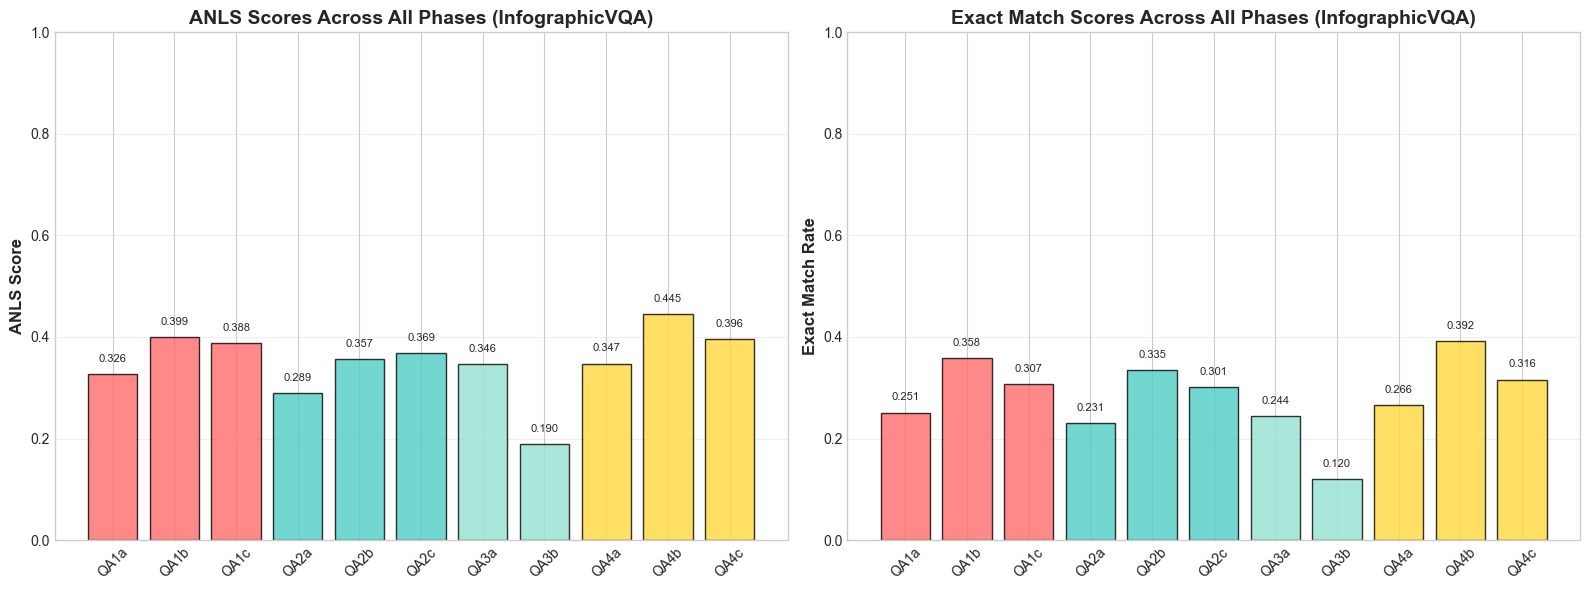


✓ Phase performance visualization complete

Color Legend:
  Red: QA1 (OCR Pipeline)
  Teal: QA2 (VLM Parse Pipeline)
  Green: QA3 (Direct VQA)
  Yellow: QA4 (Pre-extracted OCR Pipeline) ⭐


In [17]:
# Create phase performance visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ANLS Scores
ax1 = axes[0]
phases = comprehensive_df['Phase'].values
anls_scores = comprehensive_df['ANLS'].values
colors = ['#FF6B6B' if p.startswith('QA1') else '#4ECDC4' if p.startswith('QA2') else '#95E1D3' if p.startswith('QA3') else '#FFD93D' for p in phases]

ax1.bar(phases, anls_scores, color=colors, alpha=0.8, edgecolor='black')
ax1.set_ylabel('ANLS Score', fontsize=12, fontweight='bold')
ax1.set_title('ANLS Scores Across All Phases (InfographicVQA)', fontsize=14, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (phase, score) in enumerate(zip(phases, anls_scores)):
    ax1.text(i, score + 0.02, f'{score:.3f}', ha='center', va='bottom', fontsize=8)

# Exact Match Scores
ax2 = axes[1]
em_scores = comprehensive_df['Exact Match'].values

ax2.bar(phases, em_scores, color=colors, alpha=0.8, edgecolor='black')
ax2.set_ylabel('Exact Match Rate', fontsize=12, fontweight='bold')
ax2.set_title('Exact Match Scores Across All Phases (InfographicVQA)', fontsize=14, fontweight='bold')
ax2.set_ylim([0, 1])
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for i, (phase, score) in enumerate(zip(phases, em_scores)):
    ax2.text(i, score + 0.02, f'{score:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\n✓ Phase performance visualization complete")
print("\nColor Legend:")
print("  Red: QA1 (OCR Pipeline)")
print("  Teal: QA2 (VLM Parse Pipeline)")
print("  Green: QA3 (Direct VQA)")
print("  Yellow: QA4 (Pre-extracted OCR Pipeline) ⭐")

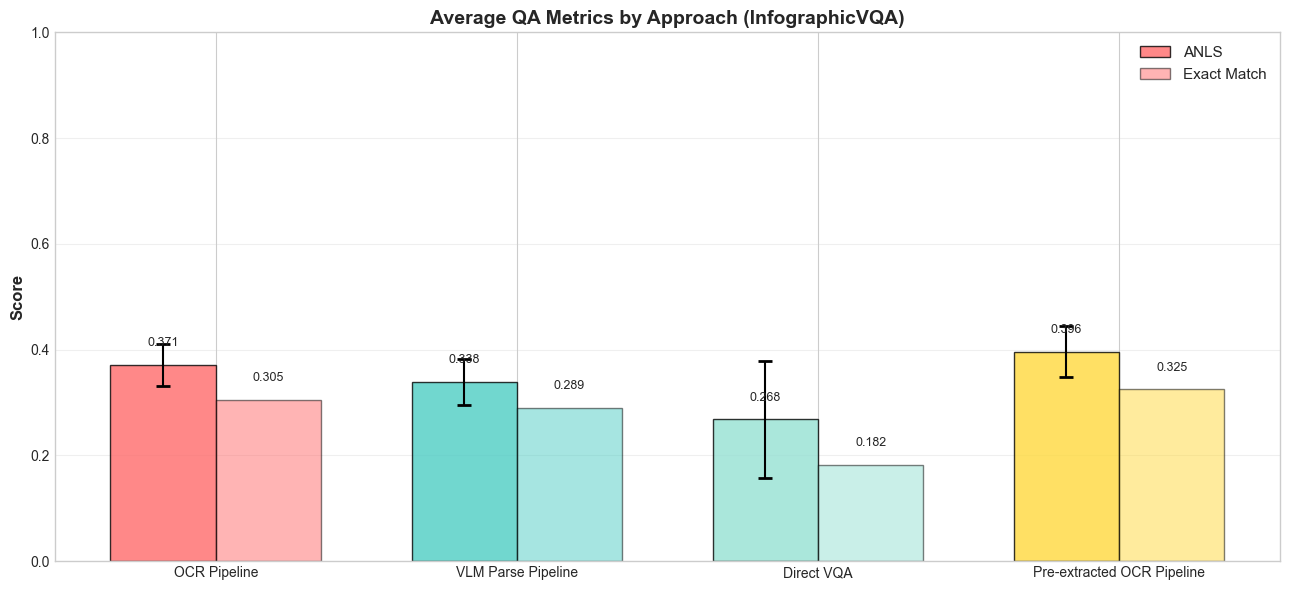


✓ Approach comparison visualization complete


In [18]:
# Approach comparison visualization
fig, ax = plt.subplots(figsize=(13, 6))

approaches = approach_metrics_data['Approach'].values
anls_avg = approach_metrics_data['Avg ANLS'].values
anls_std = approach_metrics_data['Std ANLS'].values

x = np.arange(len(approaches))
width = 0.35

colors_bar = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#FFD93D']
bars = ax.bar(x, anls_avg, width, label='ANLS', color=colors_bar, alpha=0.8, edgecolor='black')
ax.errorbar(x, anls_avg, yerr=anls_std, fmt='none', ecolor='black', capsize=5, capthick=2)

# Add EM scores as secondary
em_avg = approach_metrics_data['Avg EM'].values
ax.bar(x + width, em_avg, width, label='Exact Match', color=[c for c in colors_bar], alpha=0.5, edgecolor='black')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Average QA Metrics by Approach (InfographicVQA)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(approaches, fontsize=10)
ax.legend(fontsize=11)
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, (anls, em) in enumerate(zip(anls_avg, em_avg)):
    ax.text(i, anls + 0.03, f'{anls:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width, em + 0.03, f'{em:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Approach comparison visualization complete")

In [19]:
# Summary statistics
print("\n" + "=" * 80)
print("SUMMARY STATISTICS - InfographicVQA Mini Dataset")
print("=" * 80)

all_anls = comprehensive_df['ANLS'].values
all_em = comprehensive_df['Exact Match'].values

print(f"\nANLS Scores across all {len(all_anls)} phases:")
print(f"  Mean:   {np.mean(all_anls):.4f}")
print(f"  Std:    {np.std(all_anls):.4f}")
print(f"  Min:    {np.min(all_anls):.4f}")
print(f"  Max:    {np.max(all_anls):.4f}")
print(f"  Median: {np.median(all_anls):.4f}")

print(f"\nExact Match Scores across all {len(all_em)} phases:")
print(f"  Mean:   {np.mean(all_em):.4f}")
print(f"  Std:    {np.std(all_em):.4f}")
print(f"  Min:    {np.min(all_em):.4f}")
print(f"  Max:    {np.max(all_em):.4f}")
print(f"  Median: {np.median(all_em):.4f}")

total_samples = comprehensive_df['Samples'].sum()
print(f"\nTotal samples processed: {total_samples} across {len(PHASES)} phases")

# Special metrics for QA4 (Pre-extracted OCR)
qa4_phases = [p for p in ["QA4a", "QA4b", "QA4c"] if p in comprehensive_df['Phase'].values]
if qa4_phases:
    qa4_data = comprehensive_df[comprehensive_df['Phase'].isin(qa4_phases)]
    print(f"\n⭐ Pre-extracted OCR (QA4) Performance:")
    print(f"  Average ANLS: {qa4_data['ANLS'].mean():.4f}")
    print(f"  Best phase: {qa4_data.loc[qa4_data['ANLS'].idxmax(), 'Phase']}")


SUMMARY STATISTICS - InfographicVQA Mini Dataset

ANLS Scores across all 11 phases:
  Mean:   0.3502
  Std:    0.0643
  Min:    0.1896
  Max:    0.4451
  Median: 0.3572

Exact Match Scores across all 11 phases:
  Mean:   0.2837
  Std:    0.0703
  Min:    0.1200
  Max:    0.3920
  Median: 0.3010

Total samples processed: 5500 across 11 phases

⭐ Pre-extracted OCR (QA4) Performance:
  Average ANLS: 0.3963
  Best phase: QA4b


In [20]:
# ============================================================================
# HELPER FUNCTIONS FOR ALL METRICS ANALYSIS
# ============================================================================

# Define metric display order (used across all Section 8 analyses)
metric_order = [
    'anls_score',
    'exact_match',
    'embedding_similarity',
    'substring_match',
    'prediction_in_ground_truth',
    'ground_truth_in_prediction'
]

def extract_all_metrics(df):
    """Extract all available metrics organized by type."""
    metrics = {
        'anls_score': {},
        'exact_match': {},
        'embedding_similarity': {},
        'substring_match': {},
        'prediction_in_ground_truth': {},
        'ground_truth_in_prediction': {}
    }

    for metric_name in metrics.keys():
        cols = [c for c in df.columns if metric_name in c]
        for col in cols:
            # Extract model name from column (e.g., 'anls_score_azure_intelligence__gpt-5-mini')
            model = col.replace(f'{metric_name}_', '')
            metrics[metric_name][model] = col

    return metrics

def compute_metric_averages(df, metric_cols):
    """Compute average scores for each model."""
    results = {}
    for model, col in metric_cols.items():
        if col in df.columns:
            results[model] = df[col].mean()
    return results

### 8.5 Key Insights from Multi-Metric Analysis

The comprehensive metric analysis enables deeper understanding of model performance:

**Metric Interpretation:**
- **High ANLS + High Embedding Sim + Low Exact Match**: Semantically correct but lexically different
- **High GT-in-Pred + Low Exact Match**: Model over-generates (verbose answers)
- **High Pred-in-GT + Low Exact Match**: Model under-generates (incomplete answers)
- **High Substring Match**: Strong partial overlap regardless of order

**Error Pattern Detection:**
By comparing metrics, we can identify:
1. Lexical vs semantic errors
2. Verbosity issues (model adds extra context)
3. Incompleteness (model provides partial answers)
4. Structural understanding (substring patterns)

In [21]:
# ============================================================================
# PER-MODEL CROSS-METRIC ANALYSIS
# ============================================================================

def analyze_model_across_metrics(model_name, all_results):
    """Analyze how a single model performs across all metrics and phases."""
    print(f"\n{'=' * 80}")
    print(f"MODEL ANALYSIS: {model_name}")
    print(f"{'=' * 80}")

    model_data = []
    for phase_name, phase_df in all_results.items():
        metrics = extract_all_metrics(phase_df)
        row = {'Phase': phase_name}
        for metric_name in metric_order:
            col = metrics[metric_name].get(model_name)
            if col and col in phase_df.columns:
                row[metric_name] = phase_df[col].mean()
            else:
                row[metric_name] = np.nan
        model_data.append(row)

    model_df = pd.DataFrame(model_data)

    print("\nPerformance Across Phases:")
    print("-" * 80)
    print(model_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

    # Compute average across phases
    print("\nAverage Performance Across All Phases:")
    print("-" * 80)
    for metric_name in metric_order:
        if metric_name in model_df.columns:
            avg = model_df[metric_name].mean()
            print(f"{metric_name:35s}: {avg:.4f}")

    return model_df

# Analyze each model
first_phase_metrics = extract_all_metrics(list(all_results.values())[0])
models = list(first_phase_metrics['anls_score'].keys())

model_analyses = {}
for model in models:
    model_analyses[model] = analyze_model_across_metrics(model, all_results)


MODEL ANALYSIS: azure_intelligence__gpt-5-mini

Performance Across Phases:
--------------------------------------------------------------------------------
Phase  anls_score  exact_match  embedding_similarity  substring_match  prediction_in_ground_truth  ground_truth_in_prediction
 QA1a      0.4275       0.3380                0.6124           0.6280                      0.3400                      0.6260
 QA1b      0.6005       0.5440                0.6738           0.6460                      0.5460                      0.6440
 QA1c      0.5057       0.4140                0.6278           0.6060                      0.4140                      0.6060
 QA2a         NaN          NaN                   NaN              NaN                         NaN                         NaN
 QA2b         NaN          NaN                   NaN              NaN                         NaN                         NaN
 QA2c         NaN          NaN                   NaN              NaN                  

### 8.4 Per-Model Cross-Metric Analysis

In [22]:
# ============================================================================
# DATASET-LEVEL SUMMARY
# ============================================================================

print(f"\n{'=' * 80}")
print("DATASET-LEVEL SUMMARY (All Phases Combined)")
print(f"{'=' * 80}")

# Combine all phases
all_phases_df = pd.concat(all_results.values(), ignore_index=True)

print(f"Total Samples Across All Phases: {len(all_phases_df)}")
print(f"Number of Phases: {len(all_results)}")

# Compute dataset-level averages
dataset_metrics = extract_all_metrics(all_phases_df)
dataset_comparison = []

models = list(dataset_metrics['anls_score'].keys())
for model in models:
    row = {'Model': model}
    for metric_name in metric_order:
        col = dataset_metrics[metric_name].get(model)
        if col and col in all_phases_df.columns:
            row[metric_name] = all_phases_df[col].mean()
        else:
            row[metric_name] = np.nan
    dataset_comparison.append(row)

dataset_comparison_df = pd.DataFrame(dataset_comparison)

print("\nDataset-Wide Metric Averages:")
print("-" * 80)
print(dataset_comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Identify best overall models
print("\nBest Overall Models (Dataset-Wide):")
print("-" * 80)
for metric_name in metric_order:
    if metric_name in dataset_comparison_df.columns:
        best_idx = dataset_comparison_df[metric_name].idxmax()
        best_model = dataset_comparison_df.loc[best_idx, 'Model']
        best_score = dataset_comparison_df.loc[best_idx, metric_name]
        print(f"{metric_name:35s}: {best_model} ({best_score:.4f})")


DATASET-LEVEL SUMMARY (All Phases Combined)
Total Samples Across All Phases: 5500
Number of Phases: 11

Dataset-Wide Metric Averages:
--------------------------------------------------------------------------------
                                                          Model  anls_score  exact_match  embedding_similarity  substring_match  prediction_in_ground_truth  ground_truth_in_prediction
                                 azure_intelligence__gpt-5-mini      0.5112       0.4320                0.6380           0.6267                      0.4333                      0.6253
                 in_ground_truth_azure_intelligence__gpt-5-mini         NaN          NaN                   NaN              NaN                         NaN                         NaN
 in_ground_truth_in_ground_truth_azure_intelligence__gpt-5-mini         NaN          NaN                   NaN              NaN                         NaN                         NaN
in_ground_truth_in_ground_truth_mistral_document

### 8.3 Dataset-Level Summary (All Phases Combined)

In [23]:
# ============================================================================
# PER-EXPERIMENT DETAILED ANALYSIS
# ============================================================================

def analyze_experiment_metrics(phase_name, phase_df):
    """Detailed metric breakdown for a single experiment/phase."""
    print(f"\n{'=' * 80}")
    print(f"DETAILED ANALYSIS: {phase_name}")
    print(f"{'=' * 80}")
    print(f"Total Samples: {len(phase_df)}")

    metrics = extract_all_metrics(phase_df)
    models = list(metrics['anls_score'].keys())

    # Create comparison table
    comparison_data = []
    for model in models:
        row = {'Model': model}
        for metric_name in metric_order:
            col = metrics[metric_name].get(model)
            if col and col in phase_df.columns:
                row[metric_name] = phase_df[col].mean()
            else:
                row[metric_name] = np.nan
        comparison_data.append(row)

    comparison_df = pd.DataFrame(comparison_data)

    # Display formatted table
    print("\nMetric Averages by Model:")
    print("-" * 80)
    print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

    # Identify best model per metric
    print("\nBest Performing Models per Metric:")
    print("-" * 80)
    for metric_name in metric_order:
        if metric_name in comparison_df.columns:
            best_idx = comparison_df[metric_name].idxmax()
            best_model = comparison_df.loc[best_idx, 'Model']
            best_score = comparison_df.loc[best_idx, metric_name]
            print(f"{metric_name:35s}: {best_model} ({best_score:.4f})")

    return comparison_df

# Analyze each phase
phase_comparisons = {}
for phase_name, phase_df in all_results.items():
    phase_comparisons[phase_name] = analyze_experiment_metrics(phase_name, phase_df)


DETAILED ANALYSIS: QA1a
Total Samples: 500

Metric Averages by Model:
--------------------------------------------------------------------------------
                                                          Model  anls_score  exact_match  embedding_similarity  substring_match  prediction_in_ground_truth  ground_truth_in_prediction
                                 azure_intelligence__gpt-5-mini      0.4275       0.3380                0.6124           0.6280                      0.3400                      0.6260
                 in_ground_truth_azure_intelligence__gpt-5-mini         NaN          NaN                   NaN              NaN                         NaN                         NaN
 in_ground_truth_in_ground_truth_azure_intelligence__gpt-5-mini         NaN          NaN                   NaN              NaN                         NaN                         NaN
in_ground_truth_in_ground_truth_mistral_document_ai__gpt-5-mini         NaN          NaN                   NaN  

### 8.2 Per-Experiment (Phase) Detailed Analysis

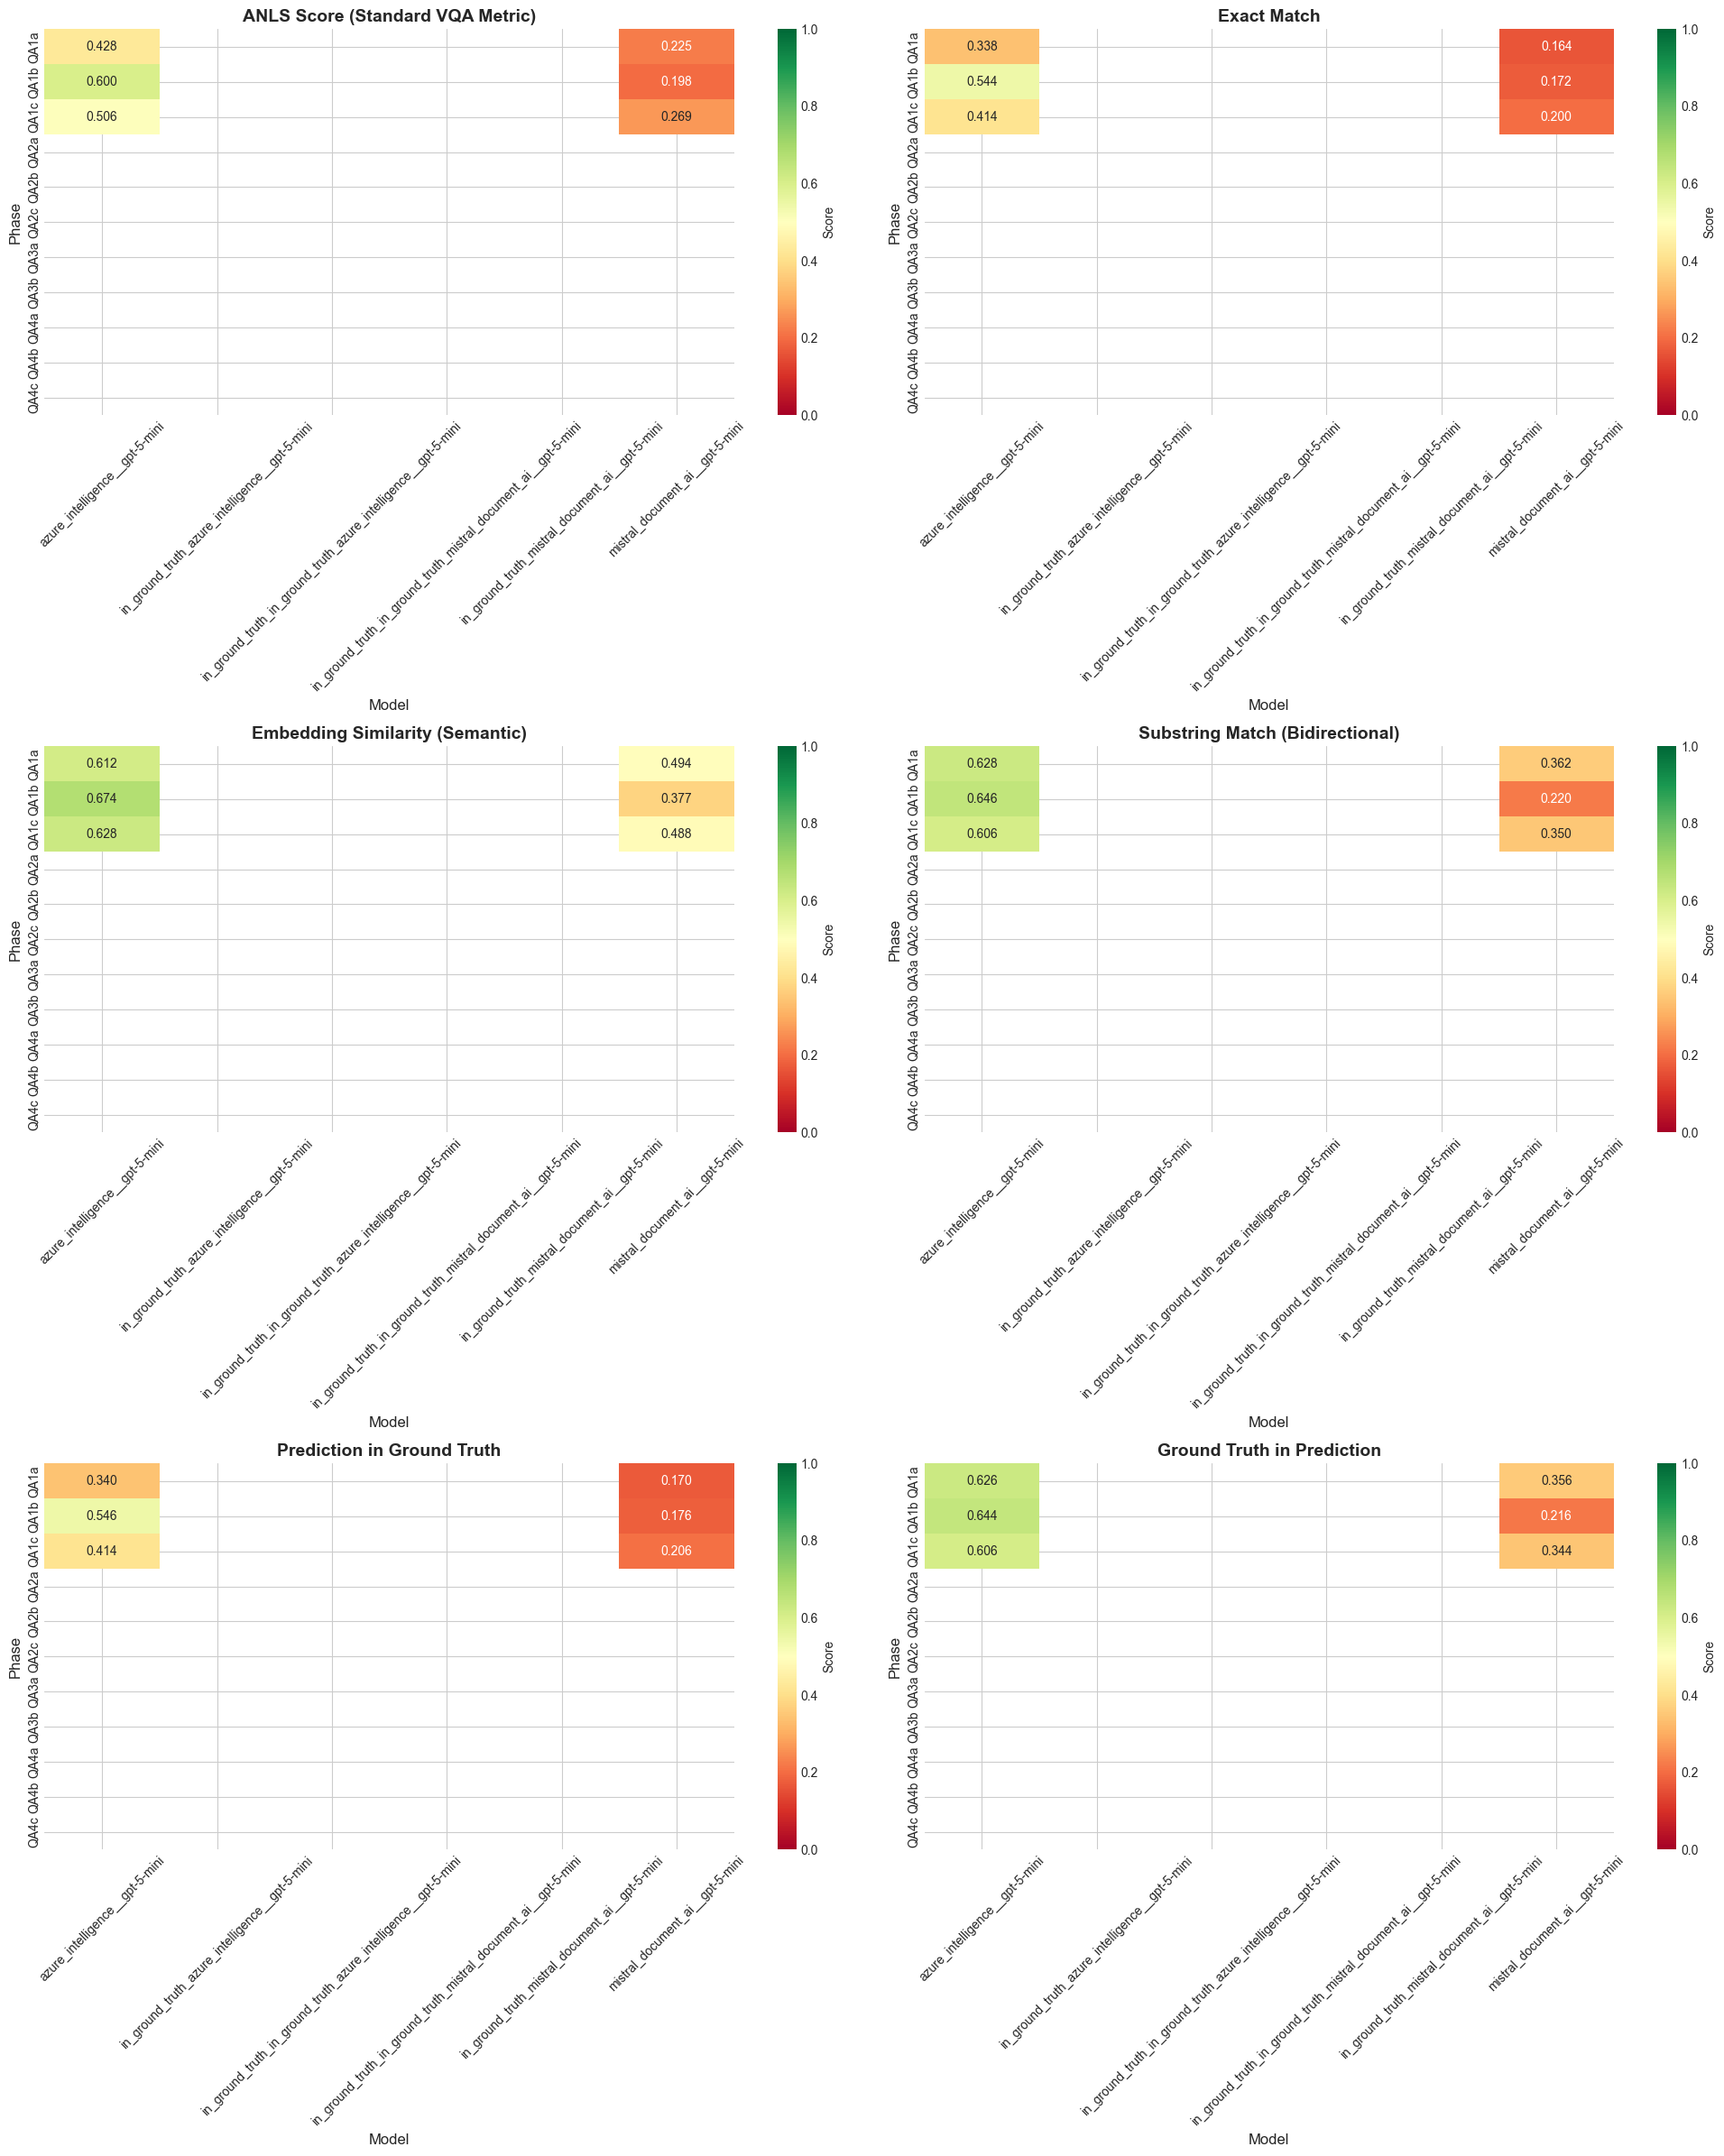


✅ Saved visualization: all_metrics_comparison.png


In [24]:
# ============================================================================
# CROSS-PHASE METRIC COMPARISON VISUALIZATION
# ============================================================================

# Prepare data for heatmap (phases x metrics for each model)
def create_metric_heatmap(all_results, models, metric_name='anls_score'):
    """Create heatmap of metric across phases and models."""
    phases = list(all_results.keys())
    data = []

    for phase in phases:
        phase_df = all_results[phase]
        phase_metrics = extract_all_metrics(phase_df)
        row = []
        for model in models:
            col = phase_metrics[metric_name].get(model)
            if col and col in phase_df.columns:
                row.append(phase_df[col].mean())
            else:
                row.append(np.nan)
        data.append(row)

    return pd.DataFrame(data, index=phases, columns=models)

# Get model list from first phase
first_phase_df = list(all_results.values())[0]
first_metrics = extract_all_metrics(first_phase_df)
models = list(first_metrics['anls_score'].keys())

# Create figure with subplots for each metric
fig, axes = plt.subplots(3, 2, figsize=(20, 24))
axes = axes.flatten()

metric_titles = {
    'anls_score': 'ANLS Score (Standard VQA Metric)',
    'exact_match': 'Exact Match',
    'embedding_similarity': 'Embedding Similarity (Semantic)',
    'substring_match': 'Substring Match (Bidirectional)',
    'prediction_in_ground_truth': 'Prediction in Ground Truth',
    'ground_truth_in_prediction': 'Ground Truth in Prediction'
}

for idx, metric_name in enumerate(metric_order):
    ax = axes[idx]

    # Create heatmap data
    heatmap_data = create_metric_heatmap(all_results, models, metric_name)

    # Plot
    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0.0, vmax=1.0, ax=ax, cbar_kws={'label': 'Score'})
    ax.set_title(metric_titles[metric_name], fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Phase', fontsize=12)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('all_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Saved visualization: all_metrics_comparison.png")

### 8.1 Cross-Phase Metric Comparison Heatmaps

In [25]:
# ============================================================================
# ALL METRICS ANALYSIS BY PHASE
# ============================================================================

print("=" * 80)
print("COMPREHENSIVE METRICS ANALYSIS")
print("=" * 80)

# Define metric display order

# Analyze each phase
for phase_name, phase_df in all_results.items():
    print(f"\n{'=' * 80}")
    print(f"Phase: {phase_name}")
    print(f"Samples: {len(phase_df)}")
    print("=" * 80)

    phase_metrics = extract_all_metrics(phase_df)

    # Get model list from first metric
    models = list(phase_metrics['anls_score'].keys())

    # Print metrics for each model
    for model in models:
        print(f"\n{model}:")
        print("-" * 80)

        for metric_name in metric_order:
            col = phase_metrics[metric_name].get(model)
            if col and col in phase_df.columns:
                avg = phase_df[col].mean()
                print(f"  {metric_name:35s}: {avg:.4f}")

COMPREHENSIVE METRICS ANALYSIS

Phase: QA1a
Samples: 500

azure_intelligence__gpt-5-mini:
--------------------------------------------------------------------------------
  anls_score                         : 0.4275
  exact_match                        : 0.3380
  embedding_similarity               : 0.6124
  substring_match                    : 0.6280
  prediction_in_ground_truth         : 0.3400
  ground_truth_in_prediction         : 0.6260

in_ground_truth_azure_intelligence__gpt-5-mini:
--------------------------------------------------------------------------------
  anls_score                         : nan
  exact_match                        : nan
  embedding_similarity               : nan
  substring_match                    : nan
  prediction_in_ground_truth         : nan
  ground_truth_in_prediction         : nan

in_ground_truth_in_ground_truth_azure_intelligence__gpt-5-mini:
--------------------------------------------------------------------------------
  anls_score       

## 8. Comprehensive Metrics Analysis

Analysis of ALL available metrics beyond ANLS and Exact Match:
- **embedding_similarity**: Semantic similarity using embeddings (0.0-1.0)
- **substring_match**: Bidirectional substring containment (0/1)
- **prediction_in_ground_truth**: Prediction appears in GT (0/1)
- **ground_truth_in_prediction**: GT appears in prediction (0/1)